# Figure 4 v6 — Prediction trace plots: M29 D23

Target: **GC unit 214**

Models ordered simplest → most complex, fit separately for VR and OF1.
Trace plot cells are standalone — adjust window / gain / model list there without re-fitting.

In [1]:
import numpy as np
import pandas as pd
import pynapple as nap
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter
from spatial_manifolds.detect_grids import *
from spatial_manifolds.mlencoding import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

plt.rcParams['font.family'] = 'Arial'

mouse       = 29
day         = 23
source_path = '/Users/harryclark/Downloads/COHORT12/'
fig_path    = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_4_xgboost/'
out_path    = fig_path   # save PDFs here

TARGET_ID      = 214      # GC unit
COL_GC         = '#c04744'
COL_TRUE       = '#444444'

HISTORY_LENGTH = 1000
N_CV           = 5
N_COV          = 10       # covariate cells per type
NFILTERS       = 5

rng = np.random.default_rng(42)

def _pad(arr, T):
    arr = np.array(arr)[:T]
    return np.pad(arr, (0, max(0, T - len(arr))))

## 1. Classify cells + build covariate pools

In [2]:
gcs, ngs, all_cells = classify_cells_both_sessions(mouse, day, source_path=source_path)

gc_ids  = set(gcs.cluster_id.values.astype(int))
ngs_ids = set(ngs.cluster_id.values.astype(int))
print(f'GC: {len(gc_ids)}  NGS: {len(ngs_ids)}')

# Covariate pools — exclude target cell
pool_gc  = sorted([c for c in gc_ids  if c != TARGET_ID])
pool_ngs = sorted([c for c in ngs_ids if c != TARGET_ID])
N_equal  = min(N_COV, len(pool_gc), len(pool_ngs))

equal_gc  = list(rng.choice(pool_gc,  size=N_equal, replace=False).astype(int))
equal_ngs = list(rng.choice(pool_ngs, size=N_equal, replace=False).astype(int))
print(f'Covariate pool: {N_equal} GC + {N_equal} NGS')

# XGBoost model
xgb = MLencoding(tunemodel='xgboost', cov_history=True, spike_history=False,
                 window=time_bs, n_filters=NFILTERS, max_time=HISTORY_LENGTH)

GC: 27  NGS: 120
Covariate pool: 10 GC + 10 NGS


## 2. Load VR data

In [3]:
print('Loading VR...')
tcs_vr, tcs_time_vr, _, last_ephys_bin_vr, beh_vr, clusters_vr = compute_vr_tcs(
    mouse, day, apply_zscore=False, apply_guassian_filter=False, source_path=source_path)
last_t_vr = clusters_vr[clusters_vr.index[0]].count(bin_size=time_bs, time_units='ms').index[-1]
ep_vr = nap.IntervalSet(start=0, end=last_t_vr, time_units='s')

y_vr = np.array(tcs_time_vr[TARGET_ID])
T_vr = len(y_vr)

def _bvr(k):
    a = np.array(beh_vr[k].bin_average(bin_size=time_bs, time_units='ms', ep=ep_vr))
    return pd.Series(a).ffill().bfill().values[:T_vr]

tns        = beh_vr['trial_number']
dt         = beh_vr['travel'] - ((tns[0] - 1) * tl)
pos_vr_raw = np.array(dt.bin_average(bin_size=time_bs, time_units='ms', ep=ep_vr))
pos_vr     = pd.Series(pos_vr_raw % tl).ffill().bfill().values[:T_vr]   # linearised position
spd_vr     = _bvr('S')

# LFP for target cell
try:
    lfp_vr = _pad(get_theta_trace(mouse=mouse, day=day, cluster_id=TARGET_ID,
                                  time_bs=50, resample_bs=time_bs,
                                  session_type='VR', source_path=source_path), T_vr)
    print('VR LFP loaded')
except Exception as e:
    print(f'VR LFP fallback: {e}'); lfp_vr = np.zeros(T_vr)

# Covariate cell matrices
def make_cov_vr(ids, T):
    rows = [_pad(np.array(tcs_time_vr[i]), T) for i in ids if i in tcs_time_vr]
    return np.vstack(rows).T if rows else np.zeros((T, 0))

cells_mat_vr = np.hstack([make_cov_vr(equal_gc, T_vr), make_cov_vr(equal_ngs, T_vr)])
print(f'VR ready  T={T_vr}  cells_mat={cells_mat_vr.shape}')

Loading VR...
VR LFP loaded
VR ready  T=192467  cells_mat=(192467, 20)


## 3. VR — fit ordered models

In [4]:
p_vr  = pos_vr[:T_vr, None]
s_vr  = spd_vr[:T_vr, None]
l_vr  = lfp_vr[:T_vr, None]
cm_vr = cells_mat_vr[:T_vr]

VR_SPECS = [
    ('pos',          'Position',              p_vr),
    ('speed',        'Speed',                 s_vr),
    ('lfp',          'LFP (theta)',            l_vr),
    ('cells',        f'{N_equal} GC + {N_equal} NGS cells', cm_vr),
    ('pos+spd+lfp',  'Pos + Speed + LFP',     np.column_stack([p_vr, s_vr, l_vr])),
    ('full+cells',   'Pos + Speed + LFP + cells',
                                              np.column_stack([p_vr, s_vr, l_vr, cm_vr])),
]

vr_models = {}
for key, desc, X in VR_SPECS:
    Y_hat, pr2 = xgb.fit_cv(X, y_vr, verbose=0, continuous_folds=True, n_cv=N_CV)
    vr_models[key] = {'Y_hat': Y_hat, 'pR2': float(np.nanmean(pr2)), 'desc': desc}
    print(f'  [{key:20s}]  pR²={vr_models[key]["pR2"]:+.4f}')

print('VR fitting done.')

  [pos                 ]  pR²=+0.0473
  [speed               ]  pR²=+0.0283
  [lfp                 ]  pR²=+0.0184
  [cells               ]  pR²=+0.0705
  [pos+spd+lfp         ]  pR²=+0.0616
  [full+cells          ]  pR²=+0.0820
VR fitting done.


## 4. VR — trace plot
Adjust `VR_TRACE_WINDOW` and `VR_GAIN` here. Re-run this cell only to update the figure.

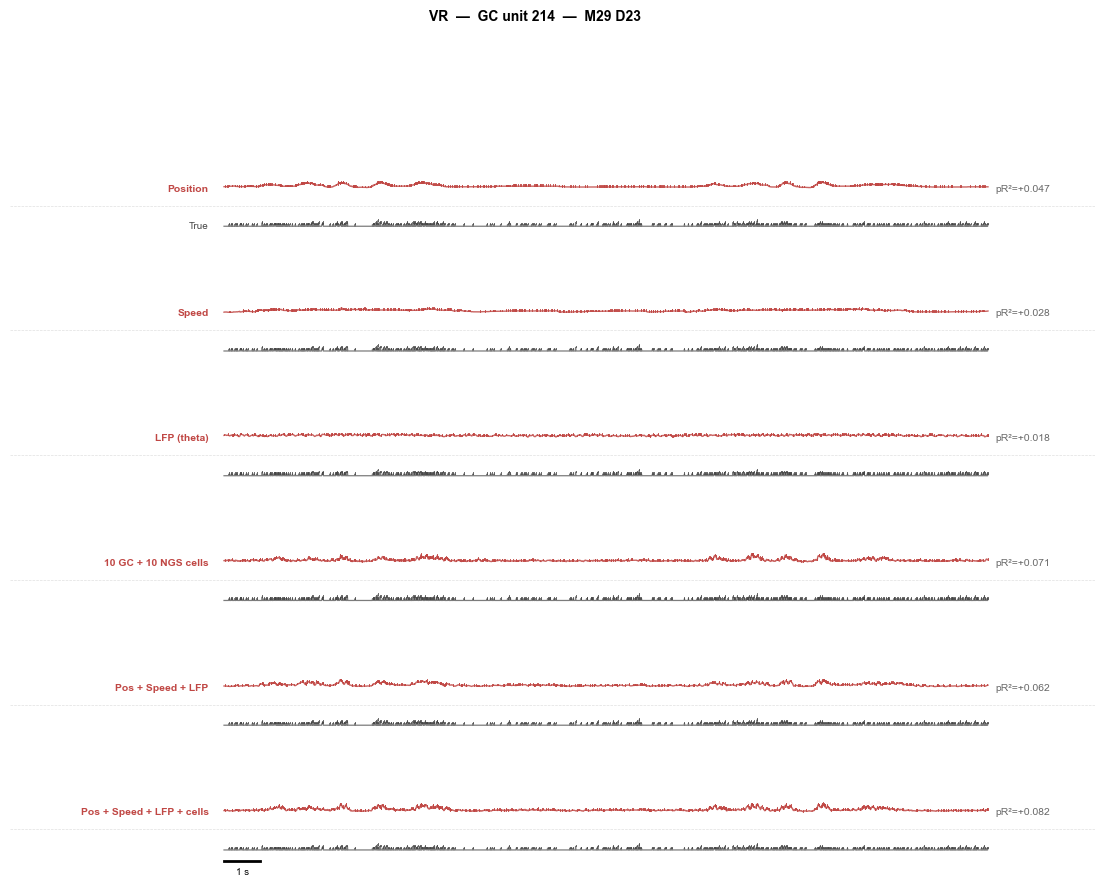

Saved VR trace figure.


In [5]:
VR_TRACE_WINDOW = (24150, 26250)   # time-bin range — adjust to a good window
VR_GAIN         = 5                # vertical scale for predicted trace

# Which models to show and in what order (must be keys from VR_SPECS above)
VR_SHOW = [
    ('pos',         'Position'),
    ('speed',       'Speed'),
    ('lfp',         'LFP (theta)'),
    ('cells',       f'{N_equal} GC + {N_equal} NGS cells'),
    ('pos+spd+lfp', 'Pos + Speed + LFP'),
    ('full+cells',  'Pos + Speed + LFP + cells'),
]

# ─────────────────────────────────────────────────────────────────────────────
win   = slice(*VR_TRACE_WINDOW)
t_idx = np.arange(*VR_TRACE_WINDOW)
y_win = y_vr[win]
y_pk  = float(np.nanmax(np.abs(y_win))) if y_win.max() > 0 else 1.0
gap   = y_pk * VR_GAIN * 1.4
rng_spk = np.random.default_rng(0)

n = len(VR_SHOW)
fig, axes = plt.subplots(n, 1, figsize=(14, n * 1.6),
                         gridspec_kw={'hspace': 0.08})

for ai, (key, label) in enumerate(VR_SHOW):
    ax   = axes[ai]
    pred = np.maximum(vr_models[key]['Y_hat'][win], 0)
    pr2  = vr_models[key]['pR2']

    # predicted trace + Poisson tick marks
    ax.plot(t_idx, pred * VR_GAIN, color=COL_GC, lw=1.0, alpha=0.85)
    for b, cnt in enumerate(rng_spk.poisson(pred)):
        for _ in range(cnt):
            yb = pred[b] * VR_GAIN
            ax.plot([t_idx[b], t_idx[b]], [yb, yb + y_pk * 0.3],
                    color=COL_GC, lw=0.7, alpha=0.9)

    # true trace below
    ax.plot(t_idx, y_win - gap, color=COL_TRUE, lw=0.9, alpha=0.7)
    for b in np.where(y_win > 0)[0]:
        ax.plot([t_idx[b], t_idx[b]],
                [-gap + y_win[b], -gap + y_win[b] + y_pk * 0.3],
                color=COL_TRUE, lw=0.7, alpha=0.8)

    ax.axhline(-gap * 0.45, color='#e0e0e0', lw=0.5, ls='--')
    ax.text(t_idx[0] - len(t_idx) * 0.02, 0,
            label, ha='right', va='center', fontsize=7.5,
            color=COL_GC, fontweight='bold')
    ax.text(t_idx[-1] + len(t_idx) * 0.01, 0,
            f'pR\u00b2={pr2:+.3f}', ha='left', va='center', fontsize=7.5, color='dimgray')
    if ai == 0:
        ax.text(t_idx[0] - len(t_idx) * 0.02, -gap,
                'True', ha='right', va='center', fontsize=7, color=COL_TRUE)

    ax.set_xlim(t_idx[0] - len(t_idx) * 0.28, t_idx[-1] + len(t_idx) * 0.14)
    ax.set_ylim(-gap * 1.5, y_pk * VR_GAIN * 2.2)
    ax.axis('off')

# 1 s scale bar
bar_len = int(1000 / time_bs)
axes[-1].plot([t_idx[0], t_idx[0] + bar_len], [-gap * 1.3, -gap * 1.3], 'k-', lw=2)
axes[-1].text(t_idx[0] + bar_len / 2, -gap * 1.48, '1 s', ha='center', va='top', fontsize=7)

fig.suptitle(f'VR  —  GC unit {TARGET_ID}  —  M{mouse} D{day}',
             fontsize=10, fontweight='bold', y=1.005)
fig.savefig(f'{out_path}M{mouse}D{day}_GC{TARGET_ID}_VR_complexity_traces.pdf',
            bbox_inches='tight', dpi=300)
plt.show()
print('Saved VR trace figure.')

## 5. Load OF1 data

In [6]:
print('Loading OF1...')
tcs_of, tcs_time_of, beh_of, clusters_of, ep_of = compute_of_tcs(
    mouse, day, apply_zscore=False, apply_guassian_filter=False,
    source_path=source_path, session='OF1')

y_of = np.array(tcs_time_of[TARGET_ID])
T_of = len(y_of)

def _bof(k):
    a = np.array(beh_of[k].bin_average(bin_size=time_bs, time_units='ms', ep=ep_of))
    return pd.Series(a).ffill().bfill().values[:T_of]

px_of   = _bof('head_x')
py_of   = _bof('head_y')
spd_of  = _bof('S')
hd_of   = _bof('H')

# LFP for target cell
try:
    lfp_of = _pad(get_theta_trace(mouse=mouse, day=day, cluster_id=TARGET_ID,
                                  time_bs=50, resample_bs=time_bs,
                                  session_type='OF1', source_path=source_path), T_of)
    print('OF1 LFP loaded')
except Exception as e:
    print(f'OF1 LFP fallback: {e}'); lfp_of = np.zeros(T_of)

# Covariate cell matrices
def make_cov_of(ids, T):
    rows = [_pad(np.array(tcs_time_of[i]), T) for i in ids if i in tcs_time_of]
    return np.vstack(rows).T if rows else np.zeros((T, 0))

cells_mat_of = np.hstack([make_cov_of(equal_gc, T_of), make_cov_of(equal_ngs, T_of)])
print(f'OF1 ready  T={T_of}  cells_mat={cells_mat_of.shape}')

Loading OF1...
OF1 LFP loaded
OF1 ready  T=120039  cells_mat=(120039, 20)


## 6. OF1 — fit ordered models

In [7]:
p2_of = np.column_stack([px_of[:T_of], py_of[:T_of]])
s_of  = spd_of[:T_of, None]
h_of  = hd_of[:T_of,  None]
l_of  = lfp_of[:T_of, None]
cm_of = cells_mat_of[:T_of]

OF_SPECS = [
    ('pos',            'Position',                   p2_of),
    ('speed',          'Speed',                      s_of),
    ('hd',             'Head direction',             h_of),
    ('lfp',            'LFP (theta)',                l_of),
    ('cells',          f'{N_equal} GC + {N_equal} NGS cells', cm_of),
    ('pos+spd+hd+lfp', 'Pos + Speed + HD + LFP',    np.column_stack([p2_of, s_of, h_of, l_of])),
    ('full+cells',     'Pos + Speed + HD + LFP + cells',
                                                     np.column_stack([p2_of, s_of, h_of, l_of, cm_of])),
]

of_models = {}
for key, desc, X in OF_SPECS:
    Y_hat, pr2 = xgb.fit_cv(X, y_of, verbose=0, continuous_folds=True, n_cv=N_CV)
    of_models[key] = {'Y_hat': Y_hat, 'pR2': float(np.nanmean(pr2)), 'desc': desc}
    print(f'  [{key:20s}]  pR\u00b2={of_models[key]["pR2"]:+.4f}')

print('OF1 fitting done.')

  [pos                 ]  pR²=+0.0043
  [speed               ]  pR²=-0.0001
  [hd                  ]  pR²=-0.0015
  [lfp                 ]  pR²=+0.0073
  [cells               ]  pR²=+0.0254
  [pos+spd+hd+lfp      ]  pR²=+0.0133
  [full+cells          ]  pR²=+0.0302
OF1 fitting done.


## 7. OF1 — trace plot
Adjust `OF_TRACE_WINDOW` and `OF_GAIN` here. Re-run this cell only to update the figure.

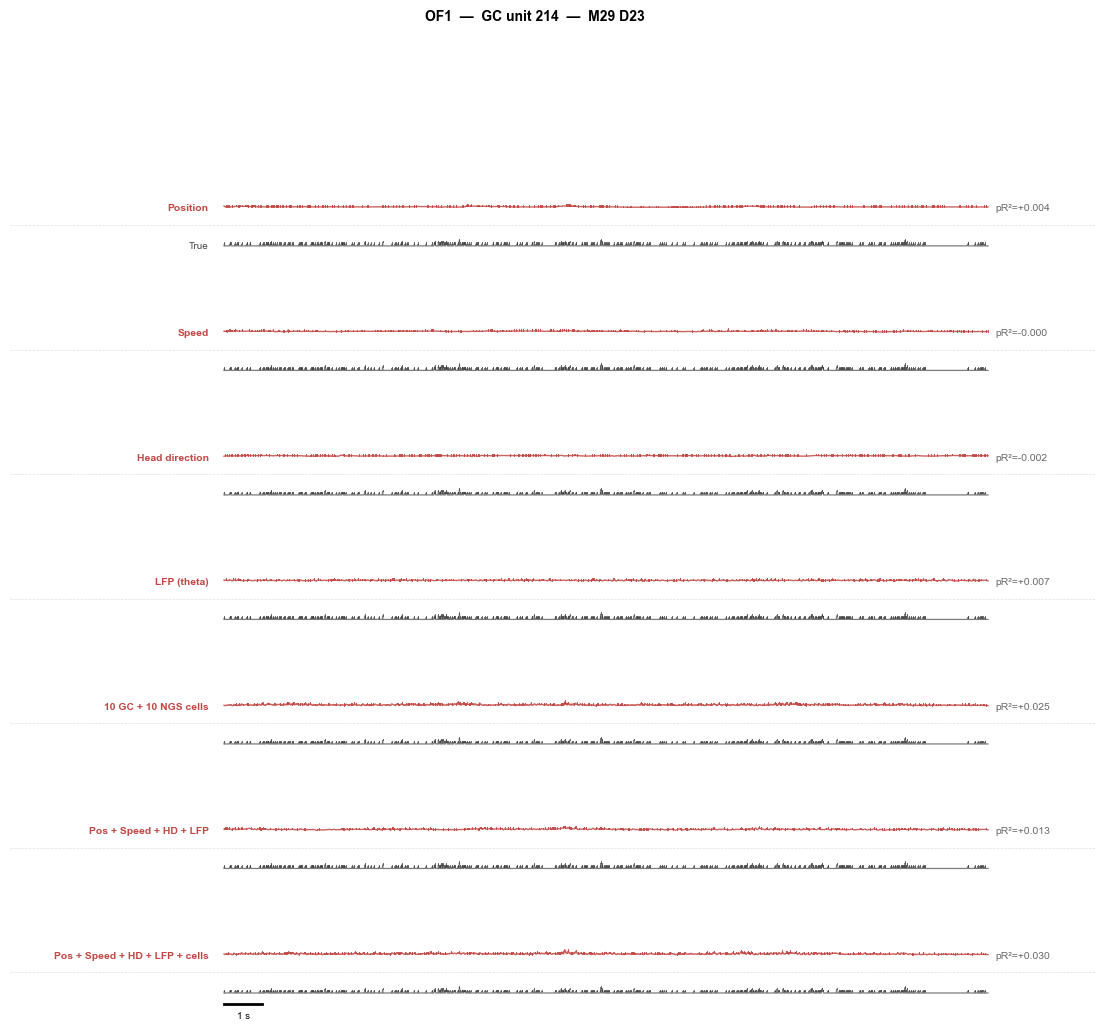

Saved OF1 trace figure.


In [8]:
OF_TRACE_WINDOW = (0, 2000)   # time-bin range — adjust to a good window
OF_GAIN         = 5           # vertical scale for predicted trace

# Which models to show and in what order (must be keys from OF_SPECS above)
OF_SHOW = [
    ('pos',            'Position'),
    ('speed',          'Speed'),
    ('hd',             'Head direction'),
    ('lfp',            'LFP (theta)'),
    ('cells',          f'{N_equal} GC + {N_equal} NGS cells'),
    ('pos+spd+hd+lfp', 'Pos + Speed + HD + LFP'),
    ('full+cells',     'Pos + Speed + HD + LFP + cells'),
]

# ─────────────────────────────────────────────────────────────────────────────
win   = slice(*OF_TRACE_WINDOW)
t_idx = np.arange(*OF_TRACE_WINDOW)
y_win = y_of[win]
y_pk  = float(np.nanmax(np.abs(y_win))) if y_win.max() > 0 else 1.0
gap   = y_pk * OF_GAIN * 1.4
rng_spk = np.random.default_rng(0)

n = len(OF_SHOW)
fig, axes = plt.subplots(n, 1, figsize=(14, n * 1.6),
                         gridspec_kw={'hspace': 0.08})

for ai, (key, label) in enumerate(OF_SHOW):
    ax   = axes[ai]
    pred = np.maximum(of_models[key]['Y_hat'][win], 0)
    pr2  = of_models[key]['pR2']

    # predicted trace + Poisson tick marks
    ax.plot(t_idx, pred * OF_GAIN, color=COL_GC, lw=1.0, alpha=0.85)
    for b, cnt in enumerate(rng_spk.poisson(pred)):
        for _ in range(cnt):
            yb = pred[b] * OF_GAIN
            ax.plot([t_idx[b], t_idx[b]], [yb, yb + y_pk * 0.3],
                    color=COL_GC, lw=0.7, alpha=0.9)

    # true trace below
    ax.plot(t_idx, y_win - gap, color=COL_TRUE, lw=0.9, alpha=0.7)
    for b in np.where(y_win > 0)[0]:
        ax.plot([t_idx[b], t_idx[b]],
                [-gap + y_win[b], -gap + y_win[b] + y_pk * 0.3],
                color=COL_TRUE, lw=0.7, alpha=0.8)

    ax.axhline(-gap * 0.45, color='#e0e0e0', lw=0.5, ls='--')
    ax.text(t_idx[0] - len(t_idx) * 0.02, 0,
            label, ha='right', va='center', fontsize=7.5,
            color=COL_GC, fontweight='bold')
    ax.text(t_idx[-1] + len(t_idx) * 0.01, 0,
            f'pR\u00b2={pr2:+.3f}', ha='left', va='center', fontsize=7.5, color='dimgray')
    if ai == 0:
        ax.text(t_idx[0] - len(t_idx) * 0.02, -gap,
                'True', ha='right', va='center', fontsize=7, color=COL_TRUE)

    ax.set_xlim(t_idx[0] - len(t_idx) * 0.28, t_idx[-1] + len(t_idx) * 0.14)
    ax.set_ylim(-gap * 1.5, y_pk * OF_GAIN * 2.2)
    ax.axis('off')

# 1 s scale bar
bar_len = int(1000 / time_bs)
axes[-1].plot([t_idx[0], t_idx[0] + bar_len], [-gap * 1.3, -gap * 1.3], 'k-', lw=2)
axes[-1].text(t_idx[0] + bar_len / 2, -gap * 1.48, '1 s', ha='center', va='top', fontsize=7)

fig.suptitle(f'OF1  —  GC unit {TARGET_ID}  —  M{mouse} D{day}',
             fontsize=10, fontweight='bold', y=1.005)
fig.savefig(f'{out_path}M{mouse}D{day}_GC{TARGET_ID}_OF1_complexity_traces.pdf',
            bbox_inches='tight', dpi=300)
plt.show()
print('Saved OF1 trace figure.')